In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Analisar sequestros
# 1. Comportamento de evolução temporal
# 2. Qual região teve mais sequestros

# Analisar roubo_celular
# 1. Comportamento de evolução temporal entre fevereiro e março ou entre novembro e dezembro
# 2. Existem DPs que registraram muito mais ocorrencias do que outras?

In [ ]:
try:
    dados = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='iso-8859-1')
    dp = pd.read_csv('08.DP.csv', sep=',', encoding='utf-8')

    # Juntar com codDP para obter o nome do DP
    df_comDP = dados.merge(dp, left_on='cisp', right_on='codDP', how='left')

    # Selecionar colunas relevantes — incluindo 'mes' e 'roubo_celular'
    df_sequestro = df_comDP[['cisp', 'codDP', 'nome', 'sequestro', 'roubo_celular', 'regiao', 'ano', 'mes']]

    # Agrupar sequestros por região e ano (para perguntas 1 e 2)
    df_sequestro_ano = df_sequestro.groupby('ano')['sequestro'].sum().reset_index()
    print(df_sequestro_ano)
except Exception as e:
    print(f"Erro ao analisar os dados: {e}")
    # print(f"Erro ao analisar os dados: {e}")


try:
    df_sequestro_regiao =  df_sequestro.groupby('regiao')['sequestro'].sum().reset_index().sort_values(by='sequestro', ascending=False)
    
    # Agrupar roubo_celular por DP, ano e mês (para perguntas 3 e 4)
    # Todas as perguntas feitas sobre roubo_celular podem ser respondidas com esse agrupamento, basta filtrar por mês ou DP depois
    # A resposta pode ser visualizada através de gráficos ou tabelas

except Exception as e:
    print(f"Erro ao analisar os dados: {e}")


     ano  sequestro
0   2003         15
1   2004         10
2   2005         10
3   2006          6
4   2007          5
5   2008          8
6   2009         11
7   2010          7
8   2011         10
9   2012         13
10  2013          3
11  2014          1
12  2015          4
13  2016         12
14  2017          8
15  2018          4
16  2019          2
17  2020          2
18  2021          3
19  2022          0
20  2023          0
21  2024          1


In [ ]:
# Visualizar os resultados
try:   # Gráfico de evolução temporal de sequestros
    plt.figure(figsize=(10, 6))
    plt.plot(df_sequestro_ano['ano'], df_sequestro_ano['sequestro'], marker='o')
    plt.title('Evolução Temporal de Sequestros')
    plt.xlabel('Ano')
    plt.ylabel('Número de Sequestros')
    plt.grid()
    plt.show()

    # Gráfico de sequestros por região
    plt.figure(figsize=(10, 6))
    plt.bar(df_sequestro_regiao['regiao'], df_sequestro_regiao['sequestro'])
    plt.title('Número de Sequestros por Região')
    plt.xlabel('Região')
    plt.ylabel('Número de Sequestros')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()

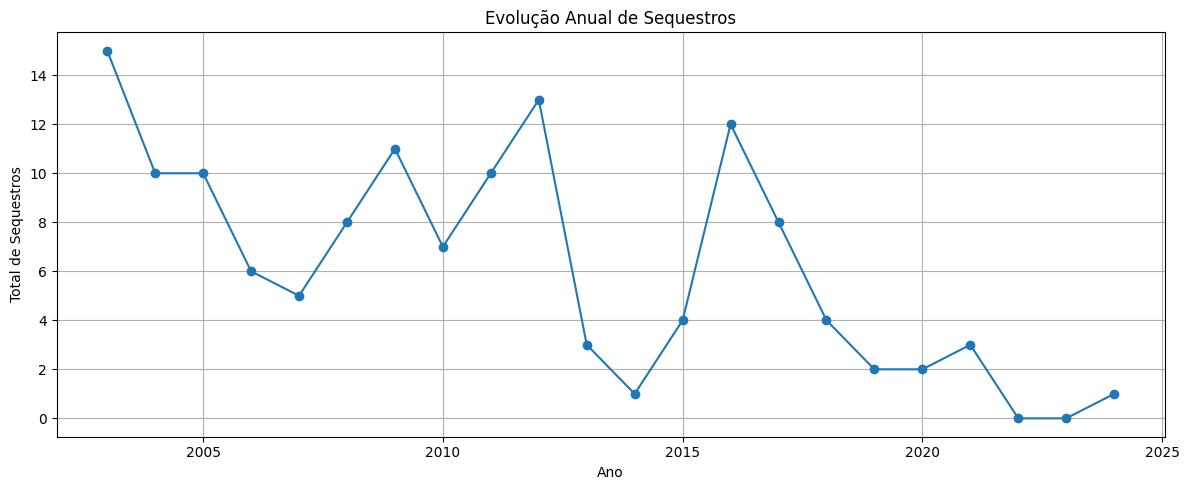

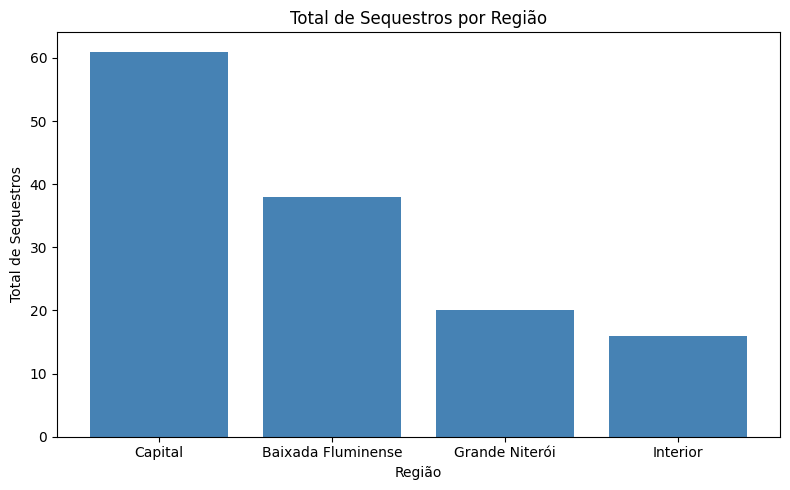

               regiao  sequestro
0             Capital         61
1  Baixada Fluminense         38
2      Grande Niterói         20
3            Interior         16


In [27]:
# --- Pergunta 1: Evolução temporal de sequestros ---
df_seq_anual = df_sequestro_agrupado.groupby('ano')['sequestro'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_seq_anual['ano'], df_seq_anual['sequestro'], marker='o')
plt.title('Evolução Anual de Sequestros')
plt.xlabel('Ano')
plt.ylabel('Total de Sequestros')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Pergunta 2: Qual região teve mais sequestros ---
df_seq_regiao = df_sequestro_agrupado.groupby('regiao')['sequestro'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(df_seq_regiao['regiao'], df_seq_regiao['sequestro'], color='steelblue')
plt.title('Total de Sequestros por Região')
plt.xlabel('Região')
plt.ylabel('Total de Sequestros')
plt.tight_layout()
plt.show()

print(df_seq_regiao)

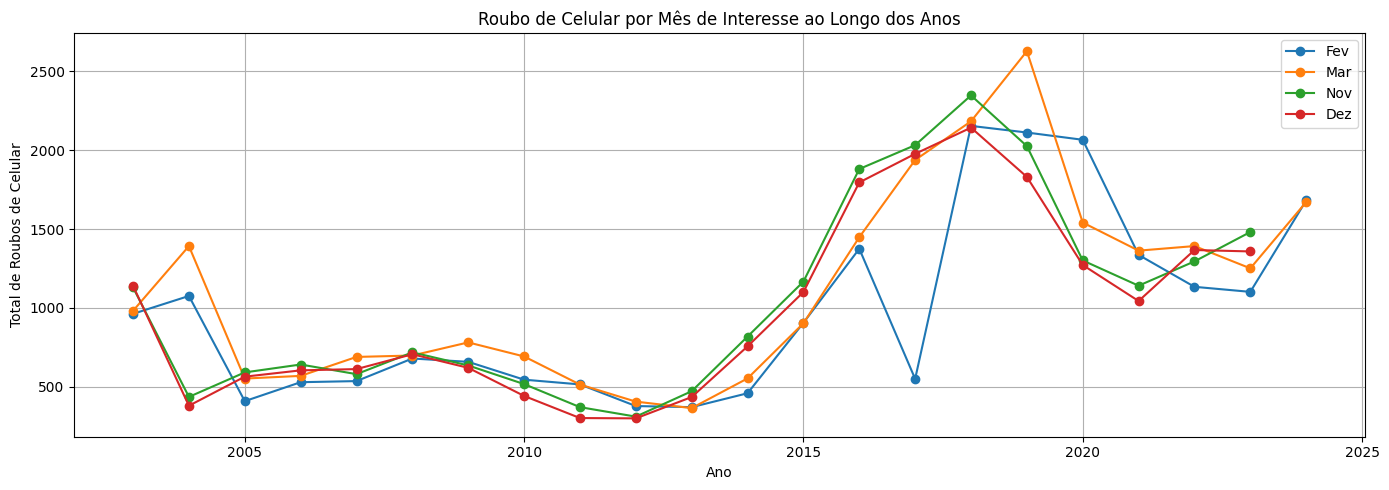

Top 10 DPs com mais roubo de celular:
   cisp                           nome  roubo_celular
0    59      059ª DP - Duque de Caxias          12319
1    64   064ª DP - São João de Meriti           9414
2    34                034ª DP - Bangu           8771
3    29            029ª DP - Madureira           7814
4    33             033ª DP - Realengo           7175
5     5            005ª DP - Mem de Sá           6912
6    23                023ª DP - Méier           6824
7    27  027ª DP - Vicente de Carvalho           6574
8    35         035ª DP - Campo Grande           6332
9    52          052ª DP - Nova Iguaçu           6262


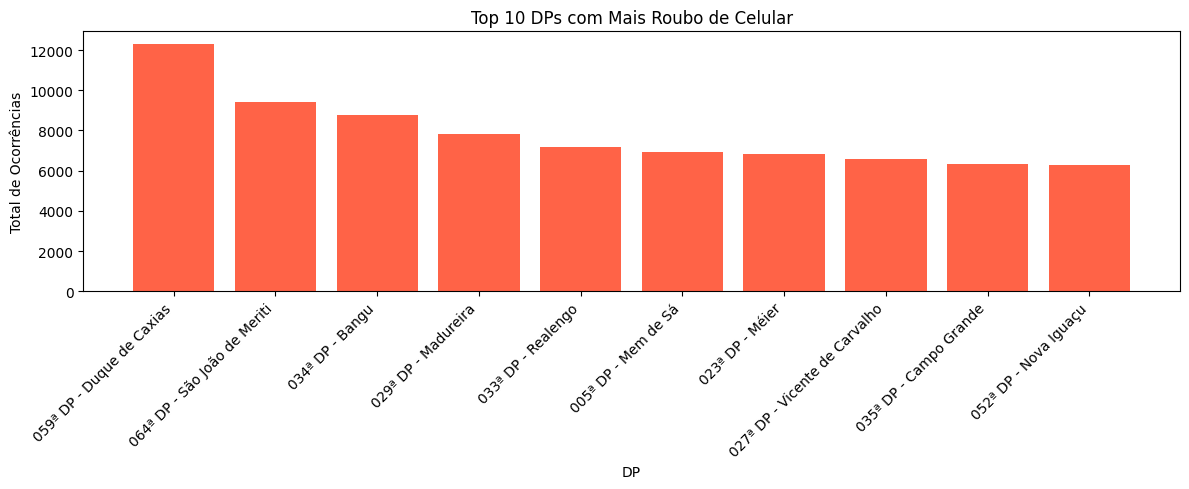

In [22]:
# --- Pergunta 3: Evolução de roubo_celular entre fevereiro/março e novembro/dezembro ---
df_celular_mensal = df_celular_agrupado.groupby(['ano', 'mes'])['roubo_celular'].sum().reset_index()

# Filtrar apenas os meses de interesse
meses_interesse = [2, 3, 11, 12]
df_celular_filtrado = df_celular_mensal[df_celular_mensal['mes'].isin(meses_interesse)]

nomes_meses = {2: 'Fev', 3: 'Mar', 11: 'Nov', 12: 'Dez'}
df_celular_filtrado = df_celular_filtrado.copy()
df_celular_filtrado['mes_nome'] = df_celular_filtrado['mes'].map(nomes_meses)
df_celular_filtrado['ano_mes'] = df_celular_filtrado['ano'].astype(str) + '-' + df_celular_filtrado['mes_nome']

plt.figure(figsize=(14, 5))
for mes_num, mes_nome in nomes_meses.items():
    df_m = df_celular_filtrado[df_celular_filtrado['mes'] == mes_num]
    plt.plot(df_m['ano'], df_m['roubo_celular'], marker='o', label=mes_nome)
plt.title('Roubo de Celular por Mês de Interesse ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Total de Roubos de Celular')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Pergunta 4: DPs com mais ocorrências de roubo_celular ---
df_celular_dp = df_celular_agrupado.groupby(['cisp', 'nome'])['roubo_celular'].sum().sort_values(ascending=False).reset_index()

print("Top 10 DPs com mais roubo de celular:")
print(df_celular_dp.head(10))

plt.figure(figsize=(12, 5))
plt.bar(df_celular_dp['nome'].head(10), df_celular_dp['roubo_celular'].head(10), color='tomato')
plt.title('Top 10 DPs com Mais Roubo de Celular')
plt.xlabel('DP')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()